# Diemtigen – Interpretable Models: Training & Evaluation 
This notebook trains and evaluates **ante-hoc interpretable** classifiers for **foreshock vs aftershock** on three input representations: 
1. **Split features** (`data_features.csv`): phase-aligned, physically interpretable descriptors on 3 segments: [0,5) noise, [5,8) P+early, [8,15] coda.
2. **Low-resolution spectrogram** (`data_lowresspec.csv`): coarse time–frequency energy bins on the post-P window [5,15] s.
3. **Hybrid**: concatenation of (1) and (2). Models implemented: 
- **Logistic Regression (L1)** — sparse linear model
- **EBM** (Explainable Boosting Machine) — boosted additive model (optionally with pairwise interactions) 

## Mathematical background (why these models are ante-hoc interpretable) 
### 1) Logistic Regression (L1) Binary class probability: 
$$
p(y=1\mid x)=\sigma\left(\beta_0+\sum_{i=1}^{d}\beta_i x_i\right),\quad
\sigma(z)=\frac{1}{1+e^{-z}}.
$$ 
- **Interpretation**: each coefficient $(\beta_i)$ is a *direct* contribution of feature $(x_i)$ to the log-odds.
- With **L1** regularization (lasso): 
$$
\min_{\beta}\; \mathcal{L}(\beta) + \lambda\sum_{i=1}^{d}|\beta_i|
$$ 
many coefficients become exactly zero → **sparse** model → easier interpretation. 

### 2) Explainable Boosting Machine (EBM) A boosted additive model (glass-box boosting): 
$$
\text{logit}(p)=\beta_0+\sum_{i=1}^{d} f_i(x_i) + \sum_{(i,j)\in \mathcal{I}} f_{ij}(x_i,x_j)
$$ 
- **Interpretation**: still additive. You inspect each $(f_i)$ curve; optionally, a *small* set of pairwise interactions $(f_{ij})$ can be included while remaining interpretable. 
--- 
## Outputs
- A metrics summary table across models and representations.
- Confusion matrices and ROC curves.
- Quick interpretability previews (coefficients / feature effects) to validate the pipeline.

In [15]:
from pathlib import Path
import numpy as np
import pandas as pd

# Input CSVs produced by the previous notebook
data_root = Path("diemtigen_data")
features_path = data_root / "data_features.csv"
spec_path = data_root / "data_lowresspec.csv"

df_feat = pd.read_csv(features_path)
df_spec = pd.read_csv(spec_path)

print("features:", df_feat.shape, "spec:", df_spec.shape)
df_feat.head()

features: (2341, 143) spec: (2341, 185)


,event_id,label,event_type,sampling_rate,npts,E_noise_rms,E_noise_peak,E_noise_energy,E_noise_std,E_noise_crest,...,Z_coda_spec_bandwidth,E_snr_rms_p_over_noise,E_coda_over_p_energy,N_snr_rms_p_over_noise,N_coda_over_p_energy,Z_snr_rms_p_over_noise,Z_coda_over_p_energy,ZHratio_noise_energy,ZHratio_p_energy,ZHratio_coda_energy
0,20140417015156,0,foreshock,120.0,1801,53.375790,120.0,1709385.0,48.988654,2.248210,...,6.760290,1.084079,2.431962,1.119927,5.549150,0.614863,4.094174,1.269386,0.400136,0.478053
1,20140417023407,0,foreshock,120.0,1801,90.630495,222.0,4928332.0,90.310153,2.449507,...,6.473917,1.147033,0.457310,1.343952,1.949502,0.795455,1.156741,1.453816,0.611481,0.616940
2,20140417030217,0,foreshock,120.0,1801,86.846435,186.0,4525382.0,83.307213,2.141711,...,6.078136,0.455075,2.429443,1.519907,1.466519,1.570888,1.292401,0.318000,1.395026,1.023748
3,20140417030538,0,foreshock,120.0,1801,74.423350,169.0,3323301.0,74.376215,2.270793,...,11.618606,1.290553,1.222610,0.896900,3.924260,0.810456,1.460216,0.989493,0.415860,0.437376
4,20140417030638,0,foreshock,120.0,1801,43.856185,117.0,1154019.0,40.634591,2.667811,...,4.397816,1.726916,1.882084,0.459145,2.846957,1.199102,3.299376,0.639783,0.924079,1.502978


In [16]:
# Build HYBRID dataframe (merge on event_id)
meta_cols = ["event_id", "label", "event_type", "sampling_rate", "npts"]
spec_only_cols = [c for c in df_spec.columns if c not in meta_cols]

df_hybrid = df_feat.merge(df_spec[["event_id"] + spec_only_cols], on="event_id", how="inner")

print("hybrid:", df_hybrid.shape)
df_hybrid.head()

hybrid: (2341, 323)


,event_id,label,event_type,sampling_rate,npts,E_noise_rms,E_noise_peak,E_noise_energy,E_noise_std,E_noise_crest,...,Z_spec_t8_f20_30,Z_spec_t8_f30_40,Z_spec_t8_f40_50,Z_spec_t8_f50_60,Z_spec_t9_f0_10,Z_spec_t9_f10_20,Z_spec_t9_f20_30,Z_spec_t9_f30_40,Z_spec_t9_f40_50,Z_spec_t9_f50_60
0,20140417015156,0,foreshock,120.0,1801,53.375790,120.0,1709385.0,48.988654,2.248210,...,14.054786,8.392216,75.441422,357.040668,234903.046817,77.104478,43.851351,14.209113,75.847605,339.643414
1,20140417023407,0,foreshock,120.0,1801,90.630495,222.0,4928332.0,90.310153,2.449507,...,11.986653,17.480699,81.640753,336.805145,115271.181087,48.901452,22.195765,9.068187,66.952310,358.808979
2,20140417030217,0,foreshock,120.0,1801,86.846435,186.0,4525382.0,83.307213,2.141711,...,14.536349,5.997800,76.756209,363.898514,233339.883498,134.603870,29.275060,4.295784,62.796343,315.112716
3,20140417030538,0,foreshock,120.0,1801,74.423350,169.0,3323301.0,74.376215,2.270793,...,32.987273,2.683972,59.645354,342.864680,332978.160077,84.766430,67.575060,9.155019,86.616641,363.366526
4,20140417030638,0,foreshock,120.0,1801,43.856185,117.0,1154019.0,40.634591,2.667811,...,16.006717,4.969292,72.532353,296.760272,11056.885373,185.903414,29.398471,6.910128,58.177126,284.138988


In [17]:
# Sanity checks: label balance
for name, df in [("features", df_feat), ("spec", df_spec), ("hybrid", df_hybrid)]:
    vc = df["event_type"].value_counts()
    print(name, vc.to_dict(), "total:", len(df))

features {'aftershock': 1172, 'foreshock': 1169} total: 2341
spec {'aftershock': 1172, 'foreshock': 1169} total: 2341
hybrid {'aftershock': 1172, 'foreshock': 1169} total: 2341


## Train/Test protocol We use a **stratified split** to preserve the foreshock/aftershock ratio. - Test set: **20%**
- Standardization: **z-score** (fit on train only). We report:
- Accuracy
- F1-score
- ROC-AUC
- Confusion matrix

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from interpret.glassbox import ExplainableBoostingClassifier

In [19]:
def split_xy(df):
    y = df["label"].astype(int).values
    X = df.drop(columns=["label", "event_type"]).copy()
    ids = X["event_id"].astype(str).values
    X = X.drop(columns=["event_id"])
    return X, y, ids

def evaluate_binary(y_true, y_prob, y_pred):
    return {
        "acc": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }

def plot_confusion(cm, title):
    fig = plt.figure()
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick = [0,1]
    plt.xticks(tick, ["foreshock","aftershock"])
    plt.yticks(tick, ["foreshock","aftershock"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    for (i,j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    plt.show()

def run_holdout(df):
    X, y, ids = split_xy(df)
    return train_test_split(X, y, test_size=0.20, random_state=0, stratify=y)

def clean_X(X: pd.DataFrame):
    X = X.copy()
    # replace inf with nan
    X = X.replace([np.inf, -np.inf], np.nan)
    # fill nan with column median (robust)
    X = X.fillna(X.median(numeric_only=True))
    # drop near-constant columns
    nunique = X.nunique(dropna=False)
    keep = nunique[nunique > 1].index
    X = X[keep]
    return X

In [20]:
datasets = {
    "split_features": df_feat,
    "lowres_spec": df_spec,
    #"hybrid": df_hybrid,
}

results = []

In [21]:
def make_logreg_l1():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            l1_ratio=1, solver="saga", C=1.0, max_iter=5000, class_weight="balanced"
        ))
    ])


def make_ebm():
    return ExplainableBoostingClassifier(
        interactions=0,       # keep additive
        max_bins=256,
        learning_rate=0.01,
        max_rounds=5000,
        outer_bags=8,
        inner_bags=0,
        random_state=0
    )
    

In [22]:
for repr_name, df in datasets.items():
    X_train, X_test, y_train, y_test = run_holdout(df)
    n_features = X_train.shape[1]
    print(f"\n=== Representation: {repr_name} | features: {n_features} ===")

    # 1) Logistic Regression L1
    logreg = make_logreg_l1()
    logreg.fit(X_train, y_train)
    prob = logreg.predict_proba(X_test)[:,1]
    pred = (prob >= 0.5).astype(int)
    m = evaluate_binary(y_test, prob, pred)
    results.append({"repr": repr_name, "model": "LogReg_L1", **m})
    print("LogReg_L1:", m)

    # 2) EBM
    ebm = make_ebm()
    ebm.fit(X_train, y_train)
    prob = ebm.predict_proba(X_test)[:,1]
    pred = (prob >= 0.5).astype(int)
    m = evaluate_binary(y_test, prob, pred)
    results.append({"repr": repr_name, "model": "EBM_additive", **m})
    print("EBM_additive:", m)


=== Representation: split_features | features: 140 ===


c:\Users\miche\OneDrive\Desktop\EQML Project\XAI-CH-antehoc\XAI\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogReg_L1: {'acc': 0.535181236673774, 'f1': 0.5439330543933054, 'roc_auc': 0.5331332969630842}
EBM_additive: {'acc': 0.6481876332622601, 'f1': 0.6597938144329897, 'roc_auc': 0.6831787597745044}

=== Representation: lowres_spec | features: 182 ===


c:\Users\miche\OneDrive\Desktop\EQML Project\XAI-CH-antehoc\XAI\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogReg_L1: {'acc': 0.5373134328358209, 'f1': 0.4965197215777262, 'roc_auc': 0.5624659028914348}
EBM_additive: {'acc': 0.6268656716417911, 'f1': 0.6187363834422658, 'roc_auc': 0.6856701218403345}


In [23]:
res_df = pd.DataFrame(results).sort_values(["acc"], ascending=[False])
res_df

,repr,model,acc,f1,roc_auc
1,split_features,EBM_additive,0.648188,0.659794,0.683179
3,lowres_spec,EBM_additive,0.626866,0.618736,0.685670
2,lowres_spec,LogReg_L1,0.537313,0.496520,0.562466
0,split_features,LogReg_L1,0.535181,0.543933,0.533133


              precision    recall  f1-score   support

   foreshock       0.62      0.65      0.63       234
  aftershock       0.63      0.60      0.62       235

    accuracy                           0.63       469
   macro avg       0.63      0.63      0.63       469
weighted avg       0.63      0.63      0.63       469



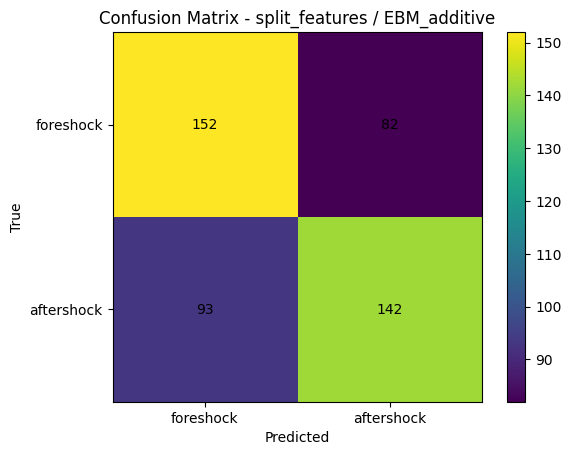

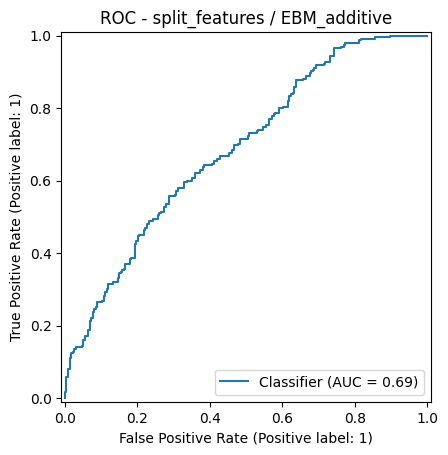

In [24]:
# Diagnostics for a chosen combination (edit here)
repr_choice = "split_features"   # "split_features", "lowres_spec" or "hybrid" 
model_choice = "EBM_additive"    # "EBM_additive", "LogReg_L1" or "(removed)"

df = datasets[repr_choice]
X_train, X_test, y_train, y_test = run_holdout(df)

if model_choice == "LogReg_L1":
    model = make_logreg_l1()
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:,1]
cm = confusion_matrix(y_test, pred)
print(classification_report(y_test, pred, target_names=["foreshock","aftershock"]))

plot_confusion(cm, f"Confusion Matrix - {repr_choice} / {model_choice}")
RocCurveDisplay.from_predictions(y_test, prob)
plt.title(f"ROC - {repr_choice} / {model_choice}")
plt.show()

## Quick interpretability previews (native) These are not post-hoc methods: they are **native model parameters / effects**. - LogReg: coefficients \ $\beta_i$
- EBM: global feature importances (and, in a separate interpretation notebook, the shape functions $(f_i)$ Below are two quick tables to confirm the pipeline is extracting meaningful signals.

In [28]:
# LogReg L1: show top coefficients
repr_choice = "split_features"
df = datasets[repr_choice]
X_train, X_test, y_train, y_test = run_holdout(df)

logreg = make_logreg_l1()
logreg.fit(X_train, y_train)

feature_names = X_train.columns.to_list()
coef = logreg.named_steps["clf"].coef_.ravel()
top = np.argsort(np.abs(coef))[::-1][:20]

pd.DataFrame({
    "feature": [feature_names[i] for i in top],
    "coef": coef[top],
}).head(10)

c:\Users\miche\OneDrive\Desktop\EQML Project\XAI-CH-antehoc\XAI\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,feature,coef
0,N_p_std,0.608002
1,N_noise_envmax,-0.544185
2,E_noise_band_10_20_pow,0.383116
3,Z_noise_std,0.348259
4,N_p_rms,-0.325115
5,N_noise_band_10_20_pow,0.284277
6,E_p_band_1_5_pow,-0.278017
7,N_coda_envmax,-0.272856
8,E_coda_std,0.259440
9,Z_noise_crest,-0.230765


In [26]:
# EBM: top global importances

repr_choice = "split_features"
df = datasets[repr_choice]

X_train, X_test, y_train, y_test = run_holdout(df)

ebm = make_ebm()
ebm.fit(X_train, y_train)

# Get global explanation
global_exp = ebm.explain_global()

# Extract feature names and importance scores
names = global_exp.data()['names']
scores = global_exp.data()['scores']

# Build dataframe of feature importances
imp_df = pd.DataFrame({
    "feature": names,
    "importance": scores
}).sort_values("importance", ascending=False)

# Show top 10
imp_df.head(10).reset_index(drop=True)

,feature,importance
0,N_coda_band_20_45_pow,0.214755
1,N_coda_band_5_10_pow,0.152634
2,N_p_band_5_10_pow,0.116150
3,Z_coda_zcr,0.072159
4,E_coda_spec_centroid,0.065942
5,Z_noise_band_20_45_pow,0.065702
6,E_coda_band_10_20_pow,0.061962
7,Z_coda_crest,0.055280
8,Z_coda_band_10_20_pow,0.048600
9,N_coda_zcr,0.046320


In [27]:
# EBM: top global importances

repr_choice = "lowres_spec"
df = datasets[repr_choice]

X_train, X_test, y_train, y_test = run_holdout(df)

ebm = make_ebm()
ebm.fit(X_train, y_train)

# Get global explanation
global_exp = ebm.explain_global()

# Extract feature names and importance scores
names = global_exp.data()['names']
scores = global_exp.data()['scores']

# Build dataframe of feature importances
imp_df = pd.DataFrame({
    "feature": names,
    "importance": scores
}).sort_values("importance", ascending=False)

# Show top 10
imp_df.head(10).reset_index(drop=True)

,feature,importance
0,N_spec_t2_f20_30,0.110293
1,Z_spec_t5_f20_30,0.094825
2,Z_spec_t0_f40_50,0.090884
3,E_spec_t5_f30_40,0.083454
4,E_spec_t8_f10_20,0.075412
5,Z_spec_t8_f40_50,0.067159
6,N_spec_t3_f20_30,0.066862
7,Z_spec_t4_f50_60,0.066252
8,N_spec_t6_f20_30,0.061182
9,Z_spec_t1_f50_60,0.057563
